In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             confusion_matrix, roc_auc_score)

sns.set_theme(style="whitegrid")
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
#load processed data
df = pd.read_csv('../data/processed_data.csv')

print(f"Shape: {df.shape}")
print(f"Fraud cases: {df['isFraud'].sum():,}")
print(f"Legitimate cases: {(df['isFraud']==0).sum():,}")

Shape: (2770409, 11)
Fraud cases: 8,213
Legitimate cases: 2,762,196


In [3]:
#train test split
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% for testing
    random_state=42,     # ensures same split every time you run
    stratify=y           # maintains fraud ratio in both splits
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"\nFraud in training set: {y_train.sum():,}")
print(f"Fraud in test set: {y_test.sum():,}")

Training set: 2,216,327 rows
Test set: 554,082 rows

Fraud in training set: 6,570
Fraud in test set: 1,643


In [4]:
#train logistic regression
lr_model = LogisticRegression(
    max_iter=1000,    # maximum iterations to converge
    random_state=42
)

lr_model.fit(X_train, y_train)
print("Model trained")

Model trained


In [5]:
#predictions and accuracy
y_pred = lr_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.4f}%")

Accuracy: 99.8112%


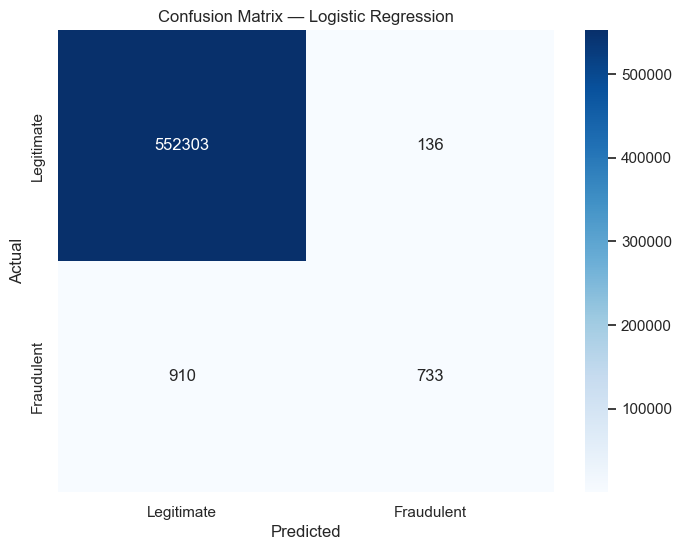


Actual fraud cases in test set: 1,643
Fraud cases caught by model: 733
Fraud cases MISSED by model: 910


In [6]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../notebooks/confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nActual fraud cases in test set: {y_test.sum():,}")
print(f"Fraud cases caught by model: {cm[1][1]:,}")
print(f"Fraud cases MISSED by model: {cm[1][0]:,}")

In [7]:
#proper metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print("=" * 40)
print("BASELINE MODEL METRICS")
print("=" * 40)
print(f"Accuracy:  {accuracy*100:.2f}%  ← misleading")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}  ← most important")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("=" * 40)
print(f"\nFraud caught: {733} / {1643} = {733/1643*100:.1f}%")
print(f"Fraud missed: {910} / {1643} = {910/1643*100:.1f}%")

BASELINE MODEL METRICS
Accuracy:  99.81%  ← misleading
Precision: 0.8435
Recall:    0.4461  ← most important
F1 Score:  0.5836
ROC-AUC:   0.7229

Fraud caught: 733 / 1643 = 44.6%
Fraud missed: 910 / 1643 = 55.4%


In [9]:
#save baseline model
import joblib

joblib.dump(lr_model, '../models/logistic_regression_baseline.joblib')
print("Baseline model saved ")

Baseline model saved 


In [10]:
#phase 3 summary
print("=" * 45)
print("PHASE 3 COMPLETE — BASELINE ESTABLISHED")
print("=" * 45)
print(f"\nLogistic Regression Results:")
print(f"  Accuracy:  99.81%  (misleading)")
print(f"  Recall:    0.4461  (catching 44.6% of fraud)")
print(f"  Precision: 0.8435")
print(f"  F1:        0.5836")
print(f"  ROC-AUC:   0.7229")
print(f"\nTarget for Phase 4:")
print(f"  Recall > 0.80  (catch 80%+ of fraud)")
print(f"  ROC-AUC > 0.90")
print("=" * 45)

PHASE 3 COMPLETE — BASELINE ESTABLISHED

Logistic Regression Results:
  Accuracy:  99.81%  (misleading)
  Recall:    0.4461  (catching 44.6% of fraud)
  Precision: 0.8435
  F1:        0.5836
  ROC-AUC:   0.7229

Target for Phase 4:
  Recall > 0.80  (catch 80%+ of fraud)
  ROC-AUC > 0.90
